In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
#handle missing value
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

/tmp/ipykernel_2129/679713519.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_2129/679713519.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [8]:
#encoding
encoder = LabelEncoder()

In [9]:
df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [10]:
#Feature Selection
X = df[["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]]
y = df["Survived"]

In [11]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
#Feature Scaling
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
#SVM Model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7821229050279329


A classification report is a performance evaluation metric in machine learning that displays the precision, recall, F1-score, and support for each class in a model. It provides a deeper, more granular view of predictive accuracy than standard accuracy alone, especially for imbalanced datasets

In [17]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



Accuracy is the overall performance of the classification model and represents the percentage of correctly predicted instances out of the total test samples. In this model, the accuracy is 78%, meaning the model correctly classified 78% of the Titanic passengers.Precision measures how many of the predicted instances for a class are actually correct. A higher precision indicates fewer false positive predictions. In this report, the precision is 0.80 for Class 0 and 0.75 for Class 1.Recall measures how many actual instances of a class are correctly identified by the model. A higher recall indicates fewer false negatives. In this report, the recall is 0.84 for Class 0 and 0.70 for Class 1.The F1-score is the harmonic mean of precision and recall, providing a balanced measure of the model's performance. It is 0.82 for Class 0 and 0.73 for Class 1, indicating better performance in predicting non-survivors.Support represents the number of actual samples belonging to each class in the test dataset. In this report, Class 0 has 105 samples and Class 1 has 74 samples, making a total of 179 test instances.Macro average is the unweighted average of precision, recall, and F1-score across all classes, treating each class equally. In this report, the macro average F1-score is 0.77.Weighted average calculates the average precision, recall, and F1-score by considering the number of samples in each class. In this report, the weighted average values are 0.78, indicating good overall model performance.

A confusion matrix is a performance measurement table for machine learning classification models. It compares a model’s predicted categories against the actual ground-truth labels, instantly revealing where the algorithm gets "confused"—such as mixing up healthy patients with sick ones.

In [18]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[88 17]
 [22 52]]


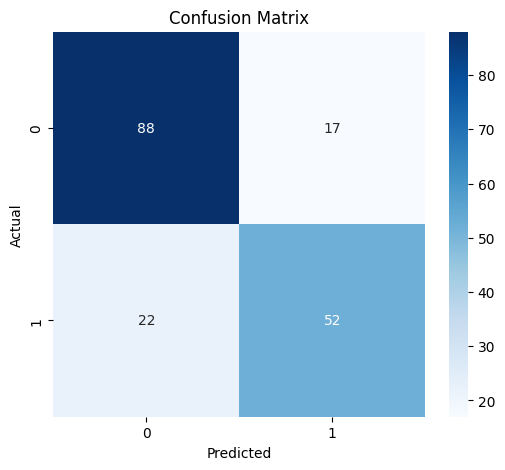

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The classification model achieved 78% accuracy, with better performance in predicting non-survivors than survivors. The precision, recall, and F1-scores suggest that the model is reliable for the Titanic survival prediction task, although there is still room for improvement in correctly identifying survivors.
The predictive model performed reasonably well on the Titanic dataset, achieving an overall accuracy of about 78%. It correctly identified most passengers who did not survive (88 cases) and a good number of those who survived (52 cases). However, the model made 17 false positive predictions and 22 false negative predictions, indicating that some survival outcomes were misclassified. Overall, the confusion matrix suggests that the model has a good balance between predicting survivors and non-survivors, but there is still room for improvement, particularly in reducing false negatives to better identify actual survivors. This demonstrates that the selected features are effective for predicting survival, although further feature engineering or more advanced algorithms could improve the model's performance.